In [6]:
import pandas as pd

df = pd.read_csv('./tmp.csv')

df

,Unnamed: 0,name,timestamp,metric,value,unit
0,0,NSW1,2025-10-04 19:00:00+10:00,price,102.599170,$/MWh
1,1,NSW1,2025-10-04 20:00:00+10:00,price,79.103333,$/MWh
2,2,NSW1,2025-10-04 21:00:00+10:00,price,72.913333,$/MWh
3,3,NSW1,2025-10-04 22:00:00+10:00,price,75.589167,$/MWh
4,4,NSW1,2025-10-04 23:00:00+10:00,price,79.127500,$/MWh
...,...,...,...,...,...,...
7425,7425,VIC1,2025-11-04 13:00:00+10:00,demand_energy,3.501900,MWh
7426,7426,VIC1,2025-11-04 14:00:00+10:00,demand_energy,3.771200,MWh
7427,7427,VIC1,2025-11-04 15:00:00+10:00,demand_energy,3.934600,MWh
7428,7428,VIC1,2025-11-04 16:00:00+10:00,demand_energy,4.468700,MWh


C:\Users\61417\AppData\Local\Temp\ipykernel_184636\2965250583.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


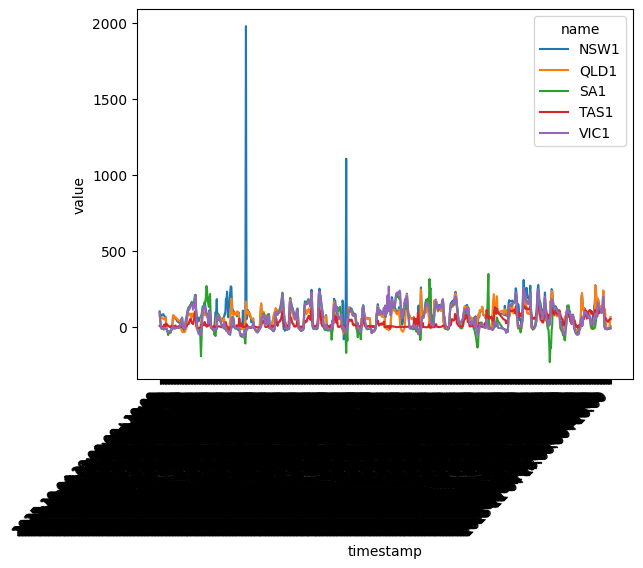

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots()
sns.lineplot(
    data=df.query('metric=="price"'),
    x='timestamp',
    y='value',
    hue='name'
)

# Rotate x-axis tick labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.show()


C:\Users\61417\AppData\Local\Temp\ipykernel_184636\3719589098.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


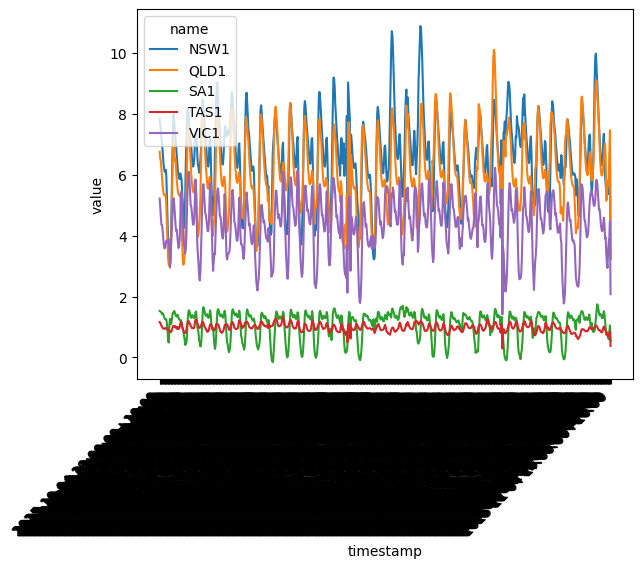

In [9]:
fig, ax = plt.subplots()
sns.lineplot(
    data=df.query('metric=="demand_energy"'),
    x='timestamp',
    y='value',
    hue='name'
)

# Rotate x-axis tick labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.show()

In [14]:
df.pivot_table(values='value', index=['name', 'timestamp'], columns = 'metric')

metric                          demand_energy       price
name timestamp                                           
NSW1 2025-10-04 19:00:00+10:00         7.8342  102.599170
     2025-10-04 20:00:00+10:00         7.6194   79.103333
     2025-10-04 21:00:00+10:00         7.3835   72.913333
     2025-10-04 22:00:00+10:00         7.2205   75.589167
     2025-10-04 23:00:00+10:00         6.9767   79.127500
...                                       ...         ...
VIC1 2025-11-04 13:00:00+10:00         3.5019   -9.312500
     2025-11-04 14:00:00+10:00         3.7712   -8.565000
     2025-11-04 15:00:00+10:00         3.9346  -11.858333
     2025-11-04 16:00:00+10:00         4.4687   -9.497500
     2025-11-04 17:00:00+10:00         2.0752   -7.334000

[3715 rows x 2 columns]

<Axes: xlabel='price', ylabel='demand_energy'>

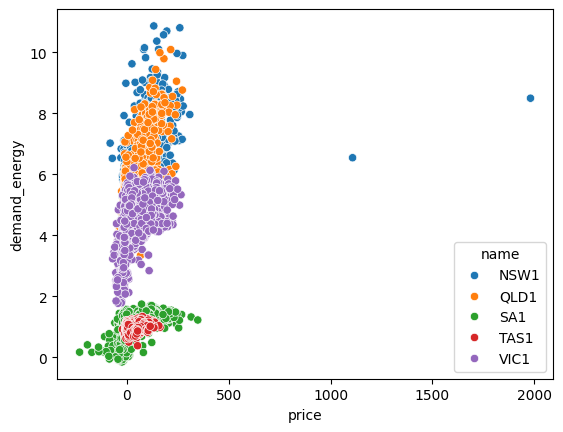

In [16]:
to_plot = df.pivot_table(values='value', index=['name',  'timestamp'], columns='metric').reset_index()
sns.scatterplot(
    data=to_plot,
    x='price',
    y='demand_energy',
    hue='name'
)

<Axes: xlabel='timestamp', ylabel='value'>

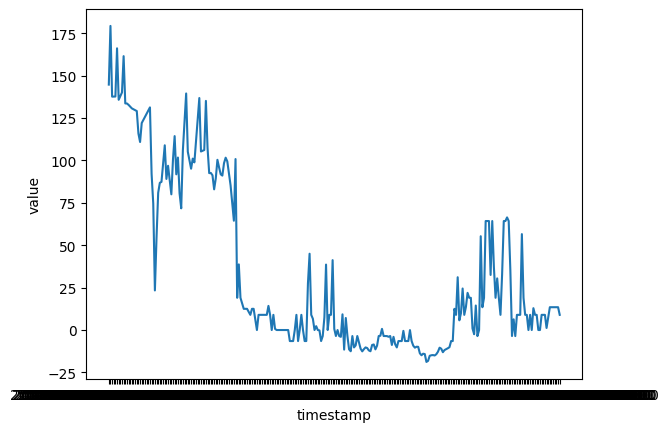

In [19]:
df = pd.read_csv('./tmp2.csv')

sns.lineplot(
    data=df,
    x='timestamp',
    y='value'
)

In [25]:
df.sort_values('timestamp')['value'].iloc[-1].item()

8.95

In [133]:
import numpy as np
from typing import Callable

class Battery:

    def __init__(
            self, 
            capacity: float, 
            loss_factor: float,
            policy: Callable[np.ndarray[float], np.ndarray[float]],
        ):

        self.capacity = capacity
        self.loss_factor = loss_factor
        self.stored_energy = 0
        self.policy = policy

    def apply_constraints(self, raw_charge_decision: float) -> float:
        upper = 1/self.loss_factor * (self.capacity - self.stored_energy)
        lower = -1/self.loss_factor * self.stored_energy
        return np.clip(raw_charge_decision, lower, upper)
    
    def make_charge_decision(self, exogenous_info: np.ndarray[float]) -> float:
        state = np.concat([np.array([self.stored_energy]), exogenous_info])
        raw_charge_decision = self.policy(state)
        charge_decision = self.apply_constraints(raw_charge_decision)
        self.stored_energy += self.loss_factor * charge_decision
        assert (self.stored_energy <= self.capacity), f"Cannot store more energy then {self.capacity}, recorded {self.stored_energy}"
        assert (self.stored_energy >= 0.0), f"Cannot store negative energy, recorded {self.stored_energy}"
        return charge_decision

In [134]:
def threshold_policy(state):
    p = state[-1]
    ## sell up to 10 if p > 25
    if p > 25:
        # print("p>25")
        return -100
    ## charge the battery if price is negative
    elif p < 0:
        return 100
    ## sell if price is not too high
    else:
        return -1
    
battery = Battery(
    capacity = 100,
    loss_factor = 1,
    policy = threshold_policy
)

# print(battery.make_charge_decision(exogenous_info=np.array([100])))
# print(battery.remaining_capacity)
# print(battery.make_charge_decision(exogenous_info=np.array([-100])))
# print(battery.remaining_capacity)

0      144.67
1      179.27
2      137.59
3      137.65
4      137.65
        ...  
270     13.45
271     13.45
272     13.45
273     13.45
274      8.95
Name: value, Length: 275, dtype: float64

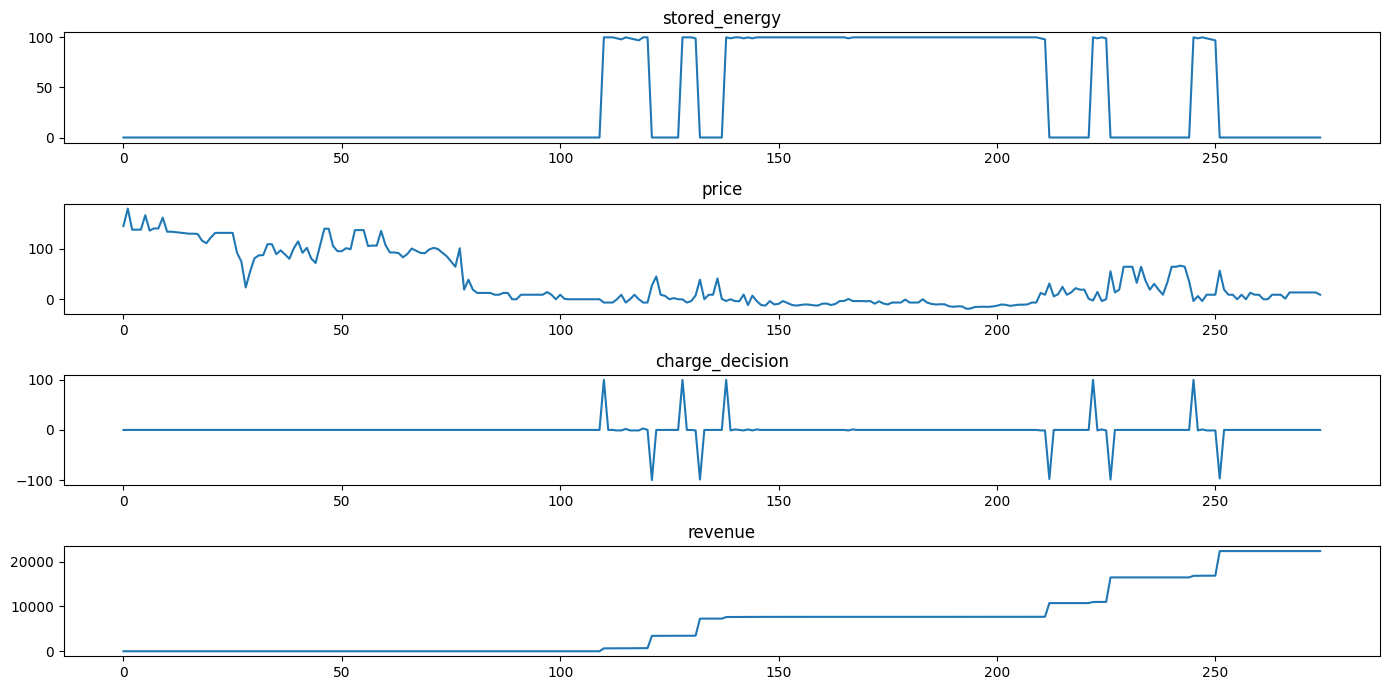

In [140]:
# price_list = [20 + (np.random.poisson(lam=25)*np.random.standard_normal(size=(1,))).item() for _ in range(100)]
price_list = df['value'].bfill().values.tolist()
results = {
    'stored_energy':[],
    'price':[],
    'charge_decision':[],
    'revenue':[]
}
for p in price_list:
    charge_decision = battery.make_charge_decision(exogenous_info=np.array([p]))
    results['revenue'].append(-p * charge_decision)
    results['stored_energy'].append(battery.stored_energy)
    results['price'].append(p)
    results['charge_decision'].append(charge_decision)

results['revenue'] = np.cumsum(results['revenue'])
fig, ax = plt.subplots(4,1, figsize = (14, 7))
for i, (k, v) in enumerate(results.items()):

    ax[i].plot(v)
    ax[i].set_title(k)

plt.tight_layout()
plt.show();



In [111]:
np.cumsum(results['revenue'])

array([-1.95457278e+01, -3.03017643e+01, -3.23331278e+01, -4.06418385e+01,
       -4.84746280e+02, -7.91641021e+02, -1.50695576e+03, -1.76688069e+03,
       -2.28735867e+03, -2.73468053e+03, -2.74981006e+03, -2.75637926e+03,
       -3.07972221e+03, -3.10370829e+03, -3.12666285e+03, -3.51036947e+03,
       -3.54741612e+03, -3.54741612e+03, -3.55047344e+03, -3.55826280e+03,
       -4.13960678e+03, -4.15578412e+03, -4.17746750e+03, -4.19655702e+03,
       -4.21181476e+03, -4.21381165e+03, -4.65350757e+03, -4.66614168e+03,
       -4.69753567e+03, -5.00523968e+03, -5.37095514e+03, -5.38233226e+03,
       -5.38659877e+03, -5.39477752e+03, -5.41240793e+03, -5.74135987e+03,
       -6.11830798e+03, -6.29041472e+03, -6.29041472e+03, -6.88307479e+03,
       -7.14027503e+03, -7.46918262e+03, -7.47916937e+03, -7.48201606e+03,
       -7.49490061e+03, -7.91073814e+03, -8.26651069e+03, -8.57027852e+03,
       -9.04507600e+03, -9.06521590e+03, -9.96071164e+03, -1.27535099e+04,
       -1.27726973e+04, -

In [27]:
import numpy as np
exogenous_info = np.array([0.1, 0.2, 0.3])
energy = np.array([1.0])

np.concat([energy, exogenous_info])

array([1. , 0.1, 0.2, 0.3])